In [634]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from aquarel import load_theme

df = pd.read_csv("../data/Retail_Transactions_Dataset.csv")

In [635]:
# look at the df
df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,12/21/2020 19:42,Cheyenne Newman,Hair Gel',6,12.77,Debit Card,New York,Convenience Store,True,Student,Winter,NaN
1,1000000001,7/6/2020 7:45,Emily Fitzgerald,"Tuna', 'Bread', 'Tissues', 'Trash Bags'",5,13.88,Debit Card,Houston,Supermarket,False,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,10/2/2021 6:28,Michael Webb,"Jam', 'Soap', 'Ketchup'",7,47.02,Debit Card,Miami,Convenience Store,False,Young Adult,Winter,NaN
3,1000000003,1/10/2022 5:39,Kimberly Lin,BBQ Sauce',9,83.86,Mobile Payment,Seattle,Warehouse Club,True,Senior Citizen,Summer,Discount on Selected Items
4,1000000004,10/13/2021 7:28,Cathy Hernandez,"Hand Sanitizer', 'Bread', 'Extension Cords', '...",4,30.55,Debit Card,Houston,Warehouse Club,False,Senior Citizen,Spring,NaN


## Cleaning

In [636]:
# check df size
df.size

390000

In [637]:
# check df shape
df.shape

(30000, 13)

In [638]:
# drop Transaction Id
df.drop(columns=["Transaction_ID"], inplace=True)

In [639]:
# fix columns
df.columns = df.columns.str.replace("_", " ")

In [640]:
# fix Product column
df.Product = df.Product.str.replace("[", "").str.replace("]", "").str.replace("'", "")

In [641]:
# change str columns to category for better performance
df["Payment Method"] = df["Payment Method"].astype("category")
df["City"] = df["City"].astype("category")
df.Season = df.Season.astype("category")
df.Promotion = df.Promotion.astype("category")

In [642]:
# also change some numeric column data types
df[["Total Items", "Total Cost"]] = df[["Total Items", "Total Cost"]].astype("int16")

In [643]:
# check NaN values
df.isna().sum()

Date                    0
Customer Name           0
Product                 0
Total Items             0
Total Cost              0
Payment Method          0
City                    0
Store Type              0
Discount Applied        0
Customer Category       0
Season                  0
Promotion            9991
dtype: int64

In [644]:
# check data types
df.dtypes

Date                      str
Customer Name             str
Product                   str
Total Items             int16
Total Cost              int16
Payment Method       category
City                 category
Store Type                str
Discount Applied         bool
Customer Category         str
Season               category
Promotion            category
dtype: object

In [645]:
# replace BOGO with "Buy One Get One"
df.Promotion = df.Promotion.str.replace("BOGO (Buy One Get One)", "Buy One Get One")

In [646]:
# replace NaN Values in Promotion columns
df.Promotion = df.Promotion.replace(np.nan, "No Promotion")

In [647]:
# drop NaN values
df.dropna(axis=0, how="any", inplace=True)

In [648]:
# drop duplicates
df.drop_duplicates(inplace=True, keep="first")

In [649]:
# check shape
df.shape

(30000, 12)

In [650]:
# create Average Order Value feature
df["Average Order Value"] = (df["Total Cost"] / df["Total Items"]).round(2)

In [651]:
# create first and middle name
df[["First", "Middle", "Last", "Another One"]] = df["Customer Name"].str.split(" ", expand=True)
# drop the other ones
df.drop(columns=["Last", "Another One"], inplace=True)

In [652]:
# convert Date to datetime
df.Date = pd.to_datetime(df.Date, errors="coerce")

# drop NaN values
df.dropna(subset="Date", inplace=True)

# create month, day, and year features
df["Month"] = df.Date.dt.month.astype("int8");
df["Day"] = df.Date.dt.day.astype("int8");
df["Year"] = df.Date.dt.year.astype("int16");

# drop Date now
df.drop(columns="Date", inplace=True)

In [653]:
# move target feature to end
col_to_move = df.pop("Discount Applied")
df.insert(len(df.columns), "Discount Applied", col_to_move)

In [654]:
# change type of target
df["Discount Applied"] = df["Discount Applied"].map({True: 1, False: 0}).astype("int8")

In [655]:
# check final df
df.head()

,Customer Name,Product,Total Items,Total Cost,Payment Method,City,Store Type,Customer Category,Season,Promotion,Average Order Value,First,Middle,Month,Day,Year,Discount Applied
0,Cheyenne Newman,Hair Gel,6,12,Debit Card,New York,Convenience Store,Student,Winter,No Promotion,2.00,Cheyenne,Newman,12,21,2020,1
1,Emily Fitzgerald,"Tuna, Bread, Tissues, Trash Bags",5,13,Debit Card,Houston,Supermarket,Professional,Fall,Buy One Get One,2.60,Emily,Fitzgerald,7,6,2020,0
2,Michael Webb,"Jam, Soap, Ketchup",7,47,Debit Card,Miami,Convenience Store,Young Adult,Winter,No Promotion,6.71,Michael,Webb,10,2,2021,0
3,Kimberly Lin,BBQ Sauce,9,83,Mobile Payment,Seattle,Warehouse Club,Senior Citizen,Summer,Discount on Selected Items,9.22,Kimberly,Lin,1,10,2022,1
4,Cathy Hernandez,"Hand Sanitizer, Bread, Extension Cords, Ice Cr...",4,30,Debit Card,Houston,Warehouse Club,Senior Citizen,Spring,No Promotion,7.50,Cathy,Hernandez,10,13,2021,0


## Exploratory Data Analysis

### Distribution of spend across payment methods

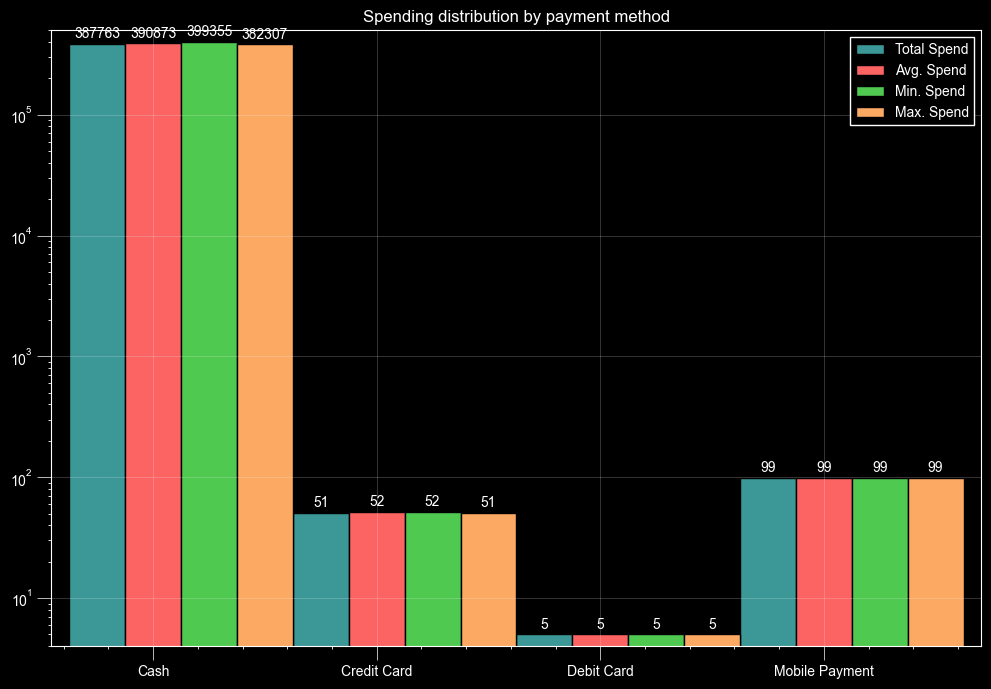

In [656]:
# set params and theme
plt.rcParams["font.family"] = "DejaVu Sans Mono"
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

theme = load_theme("boxy_dark").set_grid(alpha=0.3)
theme.apply()

paymentMethodTotalCost = df.groupby("Payment Method")["Total Cost"].agg(["sum", "mean", "min", "max"]).astype(int)
paymentMethodTotalCost.columns = ["Total Spend", "Avg. Spend", "Min. Spend", "Max. Spend"]

transactionTypes = {
    "Total Spend": paymentMethodTotalCost.iloc[0, 0:].values,
    "Avg. Spend": paymentMethodTotalCost.iloc[1, 0:].values,
    "Min. Spend": paymentMethodTotalCost.iloc[2, 0:].values,
    "Max. Spend" : paymentMethodTotalCost.iloc[3, 0:].values,
}

paymentMethods = ["Cash", "Credit Card", "Debit Card", "Mobile Payment"]
x = np.arange(len(paymentMethods))
width = 0.25
multiplier = 0

fig, axes = plt.subplots(figsize=(12, 8), dpi=100)

for transaction, values in transactionTypes.items():
  offset = width * multiplier
  rects = axes.bar(x + offset, values, width, label=transaction, edgecolor="black")
  axes.bar_label(rects, padding=2)
  multiplier += 1

axes.set_xticks(x + width, paymentMethods)
axes.set_yscale("log")
axes.legend()
axes.set_title("Spending distribution by payment method")
plt.show()

### Total items by store type

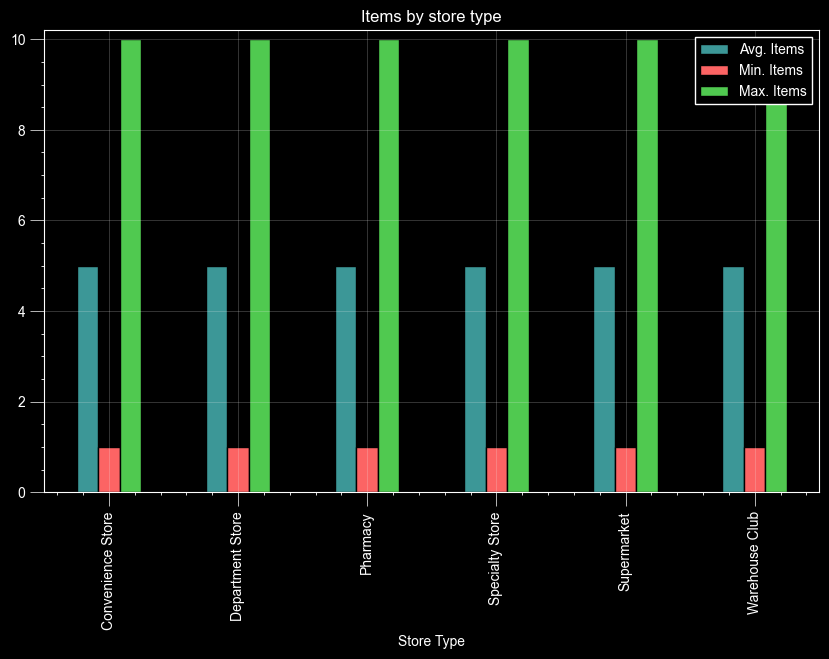

In [657]:
totalItemsStoreType = df.groupby(["Store Type"])["Total Items"].agg(["mean", "min", "max"]).astype(int)
totalItemsStoreType.columns = ["Avg. Items", "Min. Items", "Max. Items"]

totalItemsStoreType.plot(kind="bar", figsize=(10, 6), edgecolor="black", title="Items by store type")
plt.show()

### Top 20 most bougth products

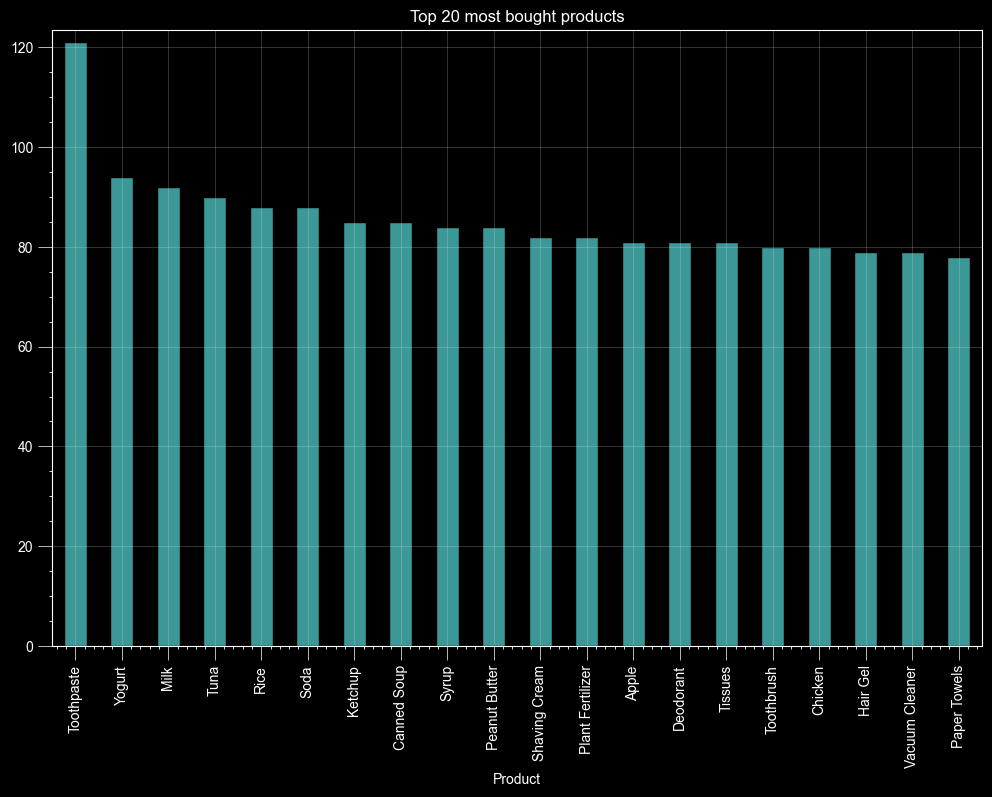

In [658]:
mostBoughtProducts = df.Product.value_counts().nlargest(20)
mostBoughtProducts.plot(kind="bar", edgecolor="black", figsize=(12, 8), title="Top 20 most bought products")
plt.show()

### Do people that buy more items also spend more in total?


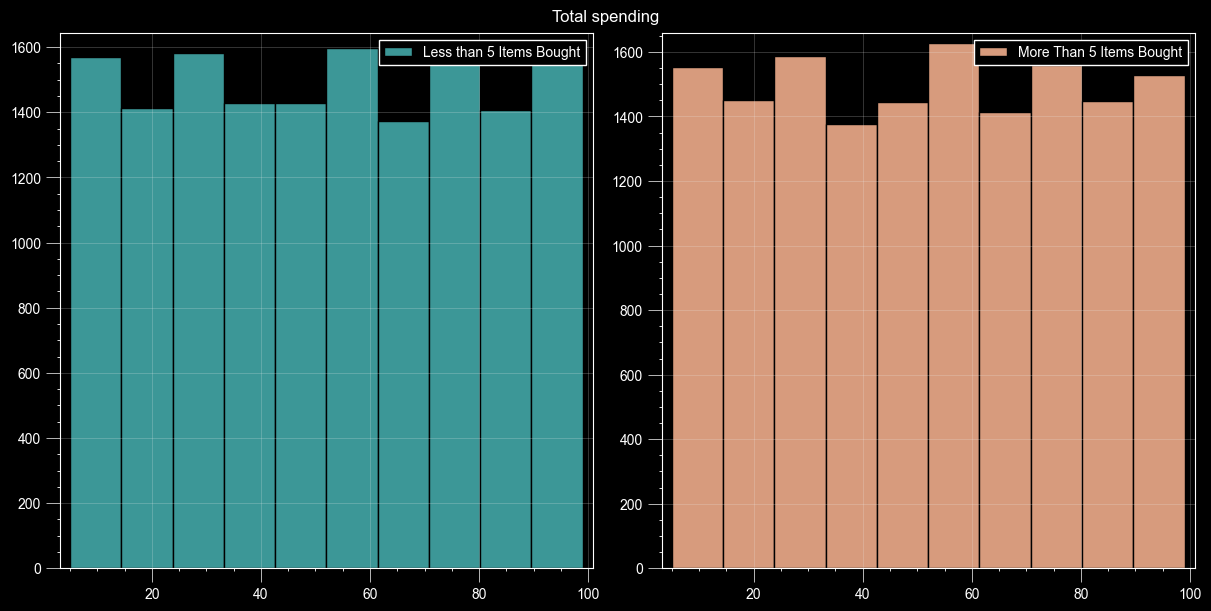

In [659]:
fiveLessItemsBought = df[df["Total Items"] <= 5]["Total Cost"].values
fiveMoreItemsBought = df[df["Total Items"] > 5]["Total Cost"].values

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), constrained_layout=True)

ax[0].hist(fiveLessItemsBought, edgecolor="black", label="Less than 5 Items Bought")
ax[0].legend()

ax[1].hist(fiveMoreItemsBought, edgecolor="black", color="#d79b7d", label="More Than 5 Items Bought")
ax[1].legend()

plt.suptitle("Total spending")
plt.show()

### Measuring how discounts affect total items and total cost


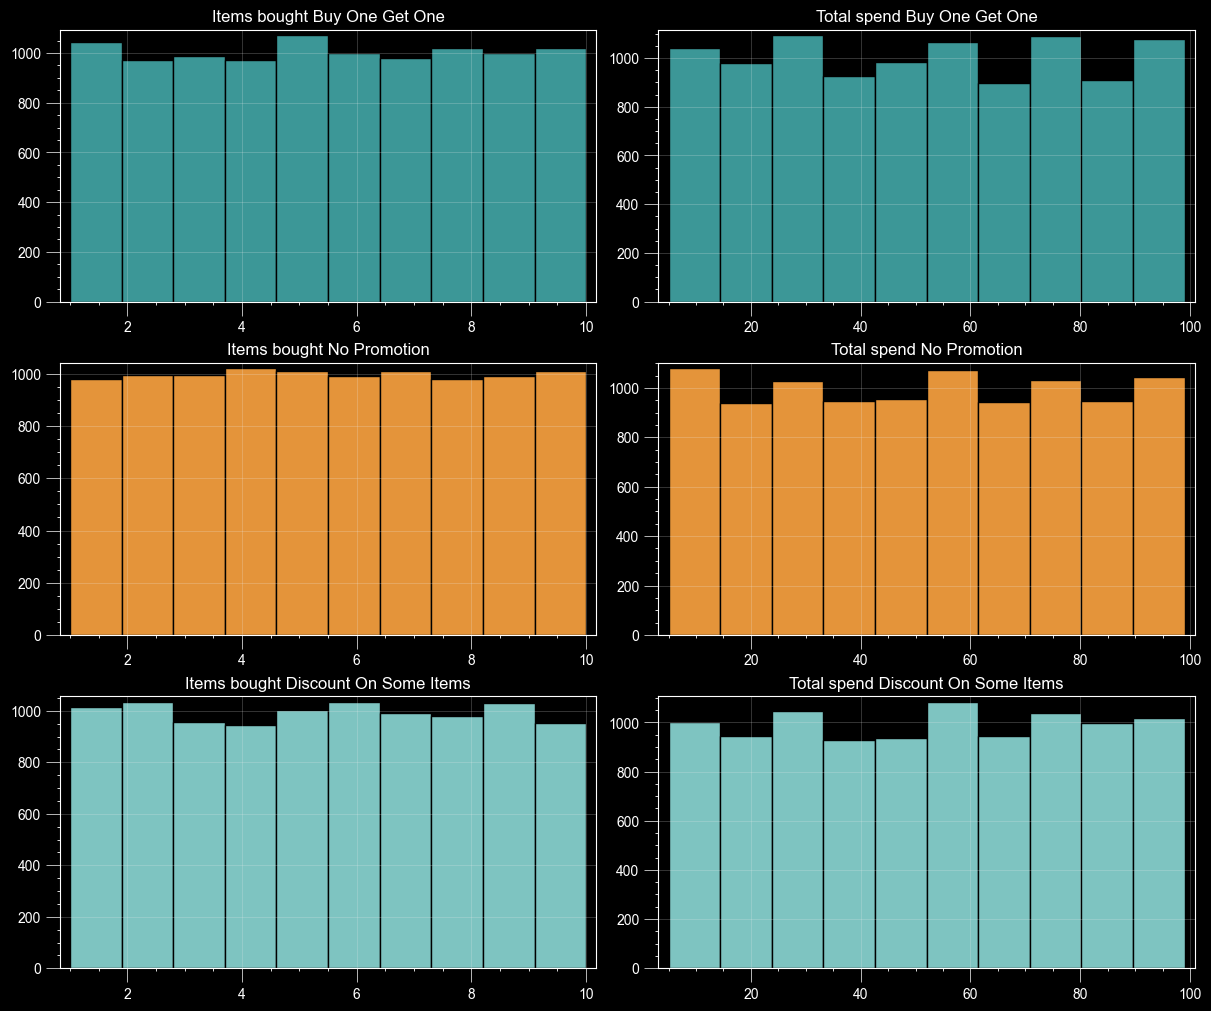

In [660]:
itemsBoughtBOGO = df[df["Promotion"] == "Buy One Get One"]["Total Items"].values
totalSpendBOGO = df[df["Promotion"] == "Buy One Get One"]["Total Cost"].values

itemsBoughtNoPromotion = df[df["Promotion"] == "No Promotion"]["Total Items"].values
totalSpendNoPromotion = df[df["Promotion"] == "No Promotion"]["Total Cost"].values

itemsBoughtDiscount = df[df["Promotion"] == "Discount on Selected Items"]["Total Items"].values
totalSpendDiscount = df[df["Promotion"] == "Discount on Selected Items"]["Total Cost"].values

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12, 10), constrained_layout=True)

ax[0, 0].hist(itemsBoughtBOGO, edgecolor="black")
ax[0, 0].set_title("Items bought Buy One Get One")

ax[0, 1].hist(totalSpendBOGO, edgecolor="black")
ax[0, 1].set_title("Total spend Buy One Get One")

ax[1, 0].hist(itemsBoughtNoPromotion, edgecolor="black", color="#e4943a")
ax[1, 0].set_title("Items bought No Promotion")

ax[1, 1].hist(totalSpendNoPromotion, edgecolor="black", color="#e4943a")
ax[1, 1].set_title("Total spend No Promotion")

ax[2, 0].hist(itemsBoughtDiscount, edgecolor="black", color="#7ec4c1")
ax[2, 0].set_title("Items bought Discount On Some Items")

ax[2, 1].hist(totalSpendDiscount, edgecolor="black", color="#7ec4c1")
ax[2, 1].set_title("Total spend Discount On Some Items")
plt.show()

### Do people spend more, on average, in certain seasons?



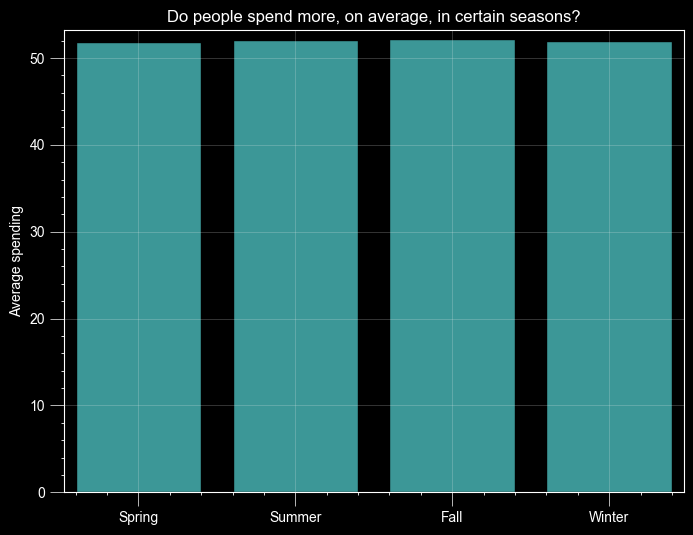

In [661]:
winterSeasonTotalCost = df.query("Season == 'Winter'")["Total Cost"].mean()
autumnSeasonTotalCost = df.query("Season == 'Fall'")["Total Cost"].mean()
springSeasonTotalCost = df.query("Season == 'Spring'")["Total Cost"].mean()
summerSeasonTotalCost = df.query("Season == 'Summer'")["Total Cost"].mean()

seasons = df["Season"].value_counts()

plt.figure(figsize=(8, 6), dpi=100)
plt.bar(seasons.index, [springSeasonTotalCost, summerSeasonTotalCost, autumnSeasonTotalCost, winterSeasonTotalCost], ec="black")
plt.title("Do people spend more, on average, in certain seasons?")
plt.ylabel("Average spending")
plt.show()

### Most common names and surnames

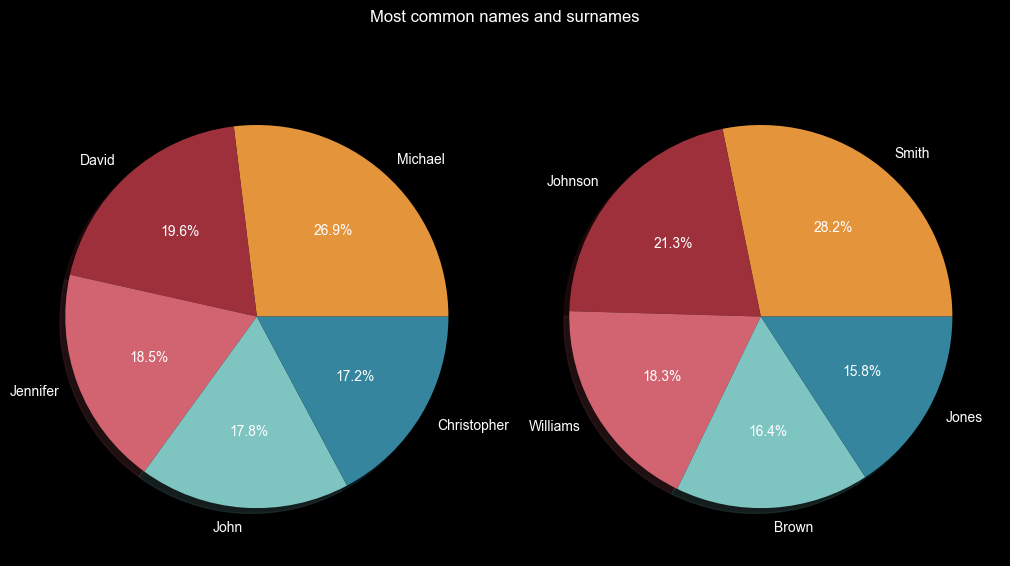

In [662]:
mostCommonNames = df.First.value_counts().nlargest(5)
mostCommonSurnames = df.Middle.value_counts().nlargest(5)
pie_colors = ["#e4943a", "#9d303b", "#d26471", "#7ec4c1", "#34859d"]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), constrained_layout=True)

ax[0].pie(mostCommonNames, labels=mostCommonNames.index, autopct='%1.1f%%', shadow=True, colors=pie_colors)
ax[1].pie(mostCommonSurnames, labels=mostCommonSurnames.index, autopct='%1.1f%%', shadow=True, colors=pie_colors)
plt.suptitle("Most common names and surnames")
plt.show()

### Average customer spend

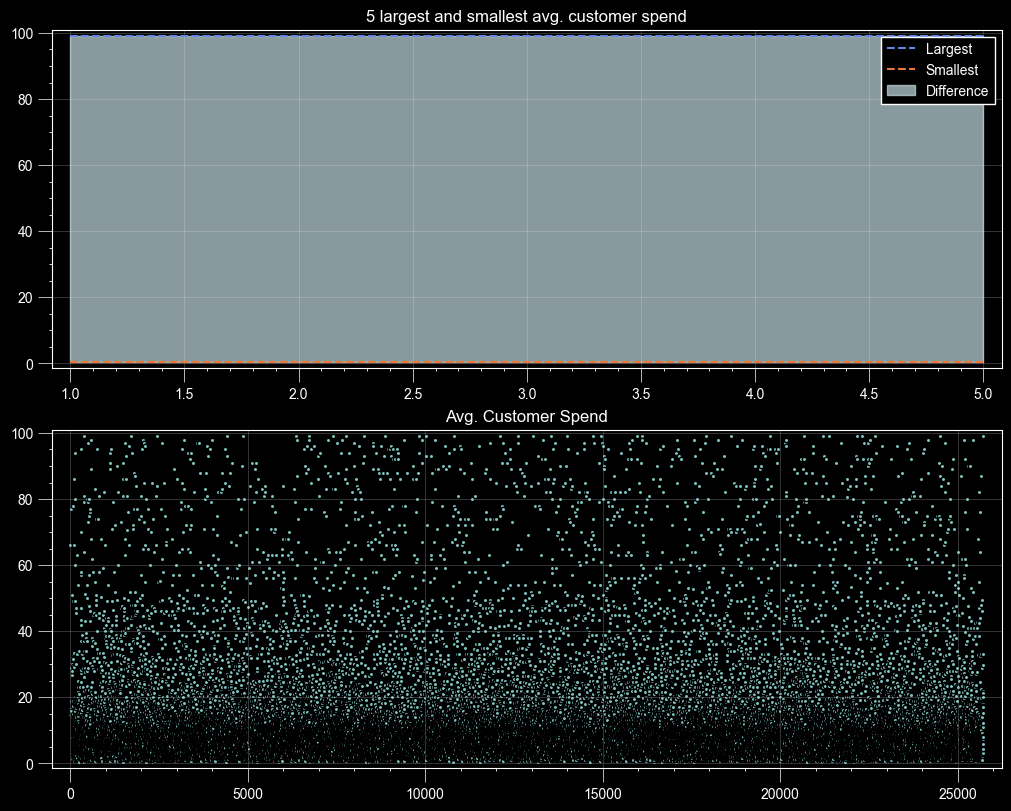

In [663]:
avgCustSpend = df.groupby("Customer Name")["Average Order Value"].agg(["mean"])
avgCustSpend.rename(columns={"mean": "Avg. Customer Spend"}, inplace=True)
avgCustSpend["Avg. Customer Spend"] = avgCustSpend.apply(lambda x: round(x, 2))

# plotting
largestCLV = avgCustSpend["Avg. Customer Spend"].nlargest(5)
lowestCLV = avgCustSpend["Avg. Customer Spend"].nsmallest(5)

xValuesFirst = np.arange(1, len(largestCLV.index) + 1, 1)
xValuesSecond = np.arange(1, len(avgCustSpend.index) + 1, 1)

fig, ax = plt.subplots(figsize=(10, 8), dpi=100, nrows=2, ncols=1, constrained_layout=True)

ax[0].plot(xValuesFirst, largestCLV, color="#6587E6", label="Largest", linestyle="--")
ax[0].plot(xValuesFirst, lowestCLV, color="#EB7738", label="Smallest", linestyle="--")
ax[0].fill_between(xValuesFirst, lowestCLV, largestCLV, color="#C5DDE3", label="Difference", alpha=0.7)
ax[0].set_title("5 largest and smallest avg. customer spend")
ax[0].legend(loc="upper right")

ax[1].scatter(xValuesSecond, avgCustSpend["Avg. Customer Spend"].values, s=10, c="#7ec4c1", ec="black")
ax[1].set_title("Avg. Customer Spend")
plt.show()

### Discount sensitivity

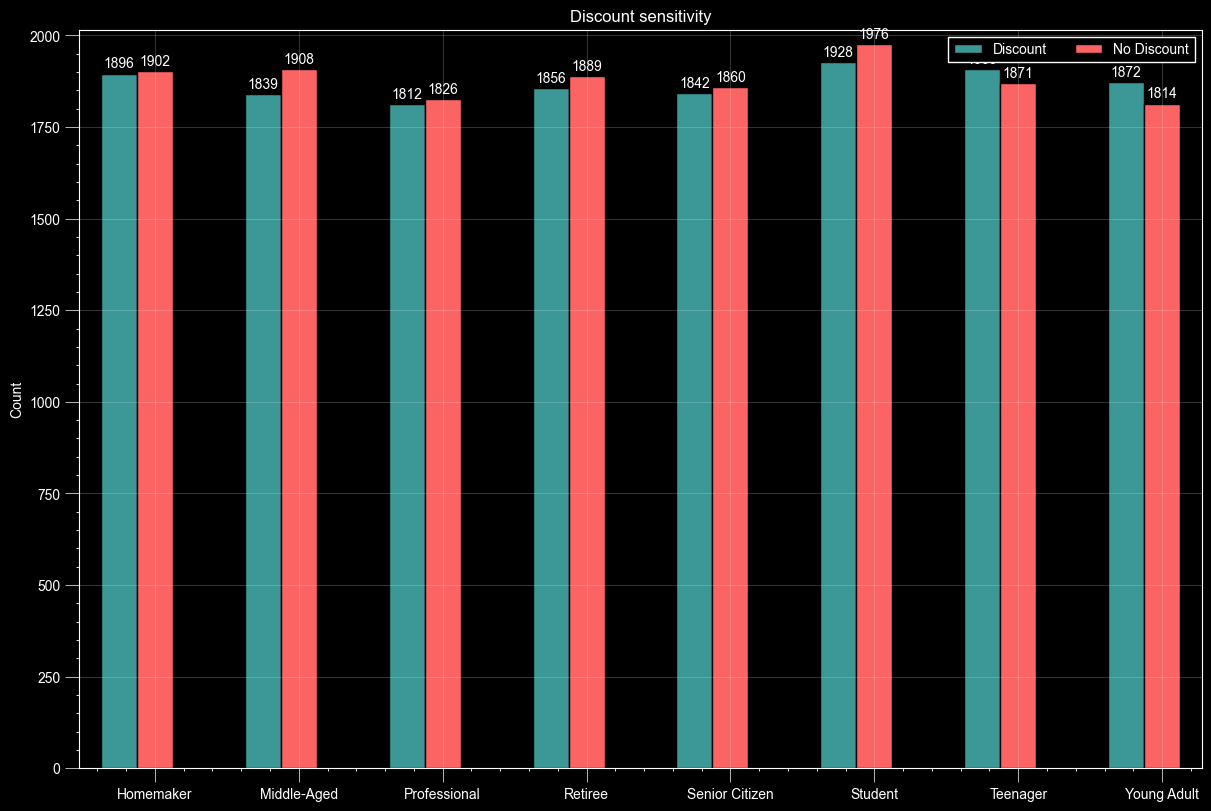

{1: array([1896, 1839, 1812, 1856, 1842, 1928, 1909, 1872]),
 0: array([1902, 1908, 1826, 1889, 1860, 1976, 1871, 1814])}

In [664]:
# second
custCategoryDiscountsApplied = df.groupby("Customer Category")["Discount Applied"].value_counts().to_frame()
custCategoryDiscountsApplied.rename(columns={"count": "Count"}, inplace=True)

# plotting
custCategories = custCategoryDiscountsApplied.index.levels[0]
discountsApplied = {
    1: custCategoryDiscountsApplied.loc[:, 1, :].values.flatten(),
    0: custCategoryDiscountsApplied.loc[:, 0, :].values.flatten(),
}

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)

x = np.arange(len(custCategories))
width = 0.25
multiplier = 0

for discount, value in discountsApplied.items():
  offset = width * multiplier
  rects = ax.bar(x + offset, value, width, label="Discount" if discount == 1 else "No Discount", ec="black")
  ax.bar_label(rects, padding=2)
  multiplier += 1

ax.set_ylabel("Count")
ax.set_xticks(x + width, custCategories)
ax.legend(loc="best", ncols=3)
ax.set_title("Discount sensitivity")
plt.show()

discountsApplied

### Comparing store type performance: which one has the highest AOV?

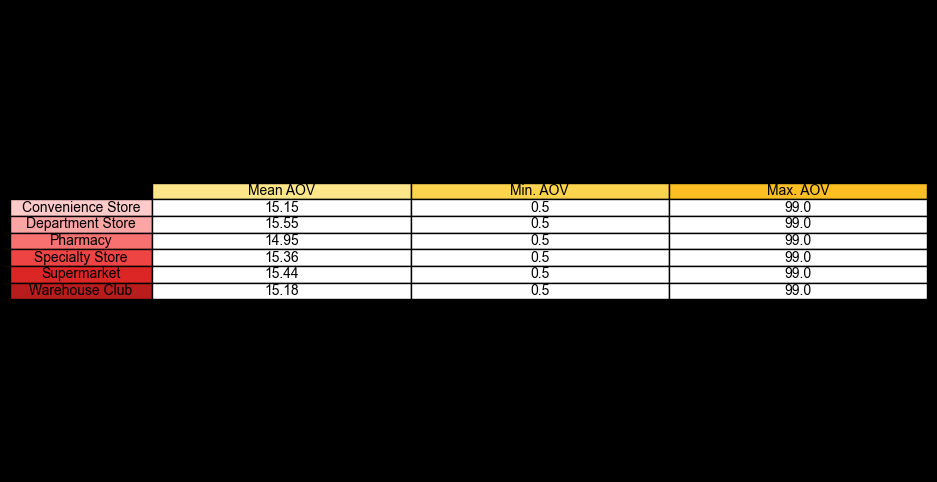

In [665]:
storeTypeAOVdf = df.groupby("Store Type")["Average Order Value"].agg(["mean", "min", "max"])
storeTypeAOVdf.columns = ["Mean AOV", "Min. AOV", "Max. AOV"]
storeTypeAOVdf = storeTypeAOVdf.apply(lambda x: round(x, 2))

storeTypeRows = storeTypeAOVdf.index
storeTypeColumns = storeTypeAOVdf.columns

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

table = ax.table(cellText=storeTypeAOVdf.values, cellLoc="center", colLabels=storeTypeColumns,
                 colLoc="center", colColours=["#fde68a", "#fcd34d", "#fbbf24"], rowLabels=storeTypeRows,
                 rowColours=["#fecaca", "#fca5a5", "#f87171", "#ef4444", "#dc2626", "#b91c1c"], rowLoc="center", loc="center")

# change color of the cell text
for cell in table.get_celld().values():
    cell.set_text_props(color="black")
plt.show()

### Seasonal trends: total items per season

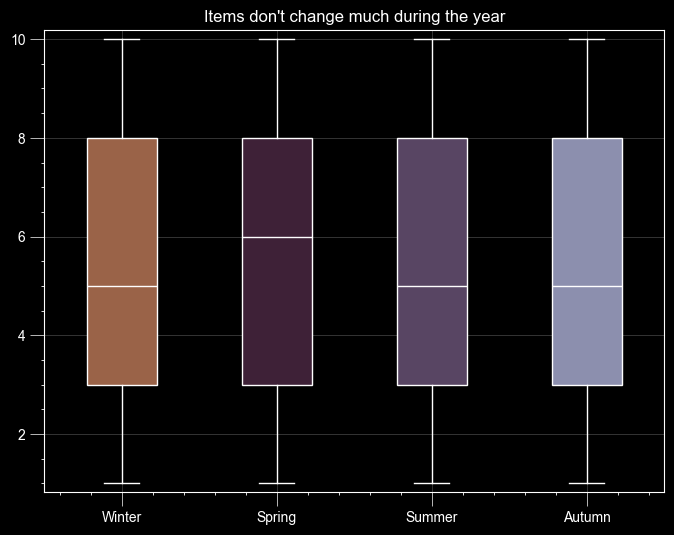

In [666]:
itemsPerSeasonWinter = df.groupby("Season").get_group("Winter")["Total Items"].values
itemsPerSeasonSpring = df.groupby("Season").get_group("Spring")["Total Items"].values
itemsPerSeasonSummer = df.groupby("Season").get_group("Summer")["Total Items"].values
itemsPerSeasonAutumn = df.groupby("Season").get_group("Fall")["Total Items"].values
seasons = ["Winter", "Spring", "Summer", "Autumn"]
items = [itemsPerSeasonWinter, itemsPerSeasonSpring, itemsPerSeasonSummer, itemsPerSeasonAutumn]
season_colors = ["#9a6348", "#3e2137", "#584563", "#8c8fae"]

plt.figure(figsize=(8, 6))
season_boxplot = plt.boxplot(items, patch_artist=True, tick_labels=seasons, meanline=True)
plt.title("Items don't change much during the year")
plt.tick_params(axis="both")

for patch, color in zip(season_boxplot["boxes"], season_colors):
    patch.set_facecolor(color)
plt.show()

### Do people buy more items in certain months?

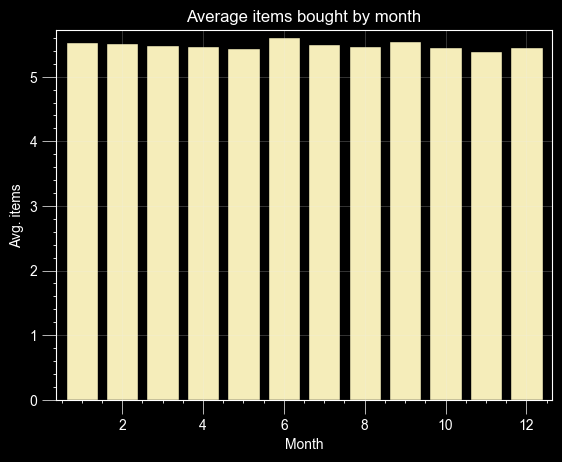

In [667]:
items_bougth_by_month = df.groupby("Month")["Total Items"].mean()

plt.bar(items_bougth_by_month.index, items_bougth_by_month.values, color="#f5edba", edgecolor="black")
plt.title("Average items bought by month")
plt.xlabel("Month")
plt.ylabel("Avg. items")
plt.show()

## Machine Learning

### Logistic regression

In [668]:
from sklearn.model_selection import train_test_split

X = df[["Payment Method", "City", "Store Type", "Customer Category", "Season", "Total Items", "Total Cost", "Month", "Day", "Year"]]
y = df["Discount Applied"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [669]:
# leaving out Promotion otherwise it could leak information
cat_features = ["Payment Method", "City", "Store Type", "Customer Category", "Season"]
num_features = ["Total Items", "Total Cost", "Month", "Day", "Year"]

In [670]:
# scale and encode features
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [671]:
# train logistic regression pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_regr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=100, random_state=42))
])

log_regr_pipeline.fit(X_train, y_train)

# predictions
y_pred_log_regr = log_regr_pipeline.predict(X_test)

In [672]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

print(f"Logistic Regression Acc. Score: {round(accuracy_score(y_test, y_pred_log_regr), 2)}")
print(f"Logistic Regression Recall: {round(recall_score(y_test, y_pred_log_regr), 2)}")
print(f"Logistic Regression Precision: {round(precision_score(y_test, y_pred_log_regr), 2)}")
print(f"Logistic Regression F1 Score: {round(f1_score(y_test, y_pred_log_regr), 2)}")

Logistic Regression Acc. Score: 0.5
Logistic Regression Recall: 0.44
Logistic Regression Precision: 0.49
Logistic Regression F1 Score: 0.47


### Random forest classifier

In [673]:
# train the classifier
from sklearn.ensemble import RandomForestClassifier

rand_for_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42))
])

rand_for_pipeline.fit(X_train, y_train)

# predictions
y_pred_rand_for = rand_for_pipeline.predict(X_test)

In [674]:
# metrics
print(f"Random Forest Acc. Score: {round(accuracy_score(y_test, y_pred_rand_for), 2)}")
print(f"Random Forest Recall: {round(recall_score(y_test, y_pred_rand_for), 2)}")
print(f"Random Forest Precision: {round(precision_score(y_test, y_pred_rand_for), 2)}")
print(f"Random Forest F1 Score: {round(f1_score(y_test, y_pred_rand_for), 2)}")

Random Forest Acc. Score: 0.51
Random Forest Recall: 0.48
Random Forest Precision: 0.51
Random Forest F1 Score: 0.49


## Exploratory Data Analysis (EDA) Conclusions

1.	The spending distribution across payment methods (cash, credit card, debit card and mobile payment) is mostly the same. Total, average, min. and max. spending are very similar. This suggests that the dataset weights each payment type roughly the same, which is the case.
2.	When looking at store types, average, min. and max. number of items purchased is roughly the same as well, with no clear differences. Furthermore, mean, min. and max. AOV (Average Order Value) is basically the same as well, with minor differences only in mean values.
3.	The most bought products are toothpaste, yogurt and milk.
4.	According to the data, promotions don’t show meaningful signs to affect buyer’s items bought and the total spending. This is the same with BOGO (Buy One Get One), No Promotion and Discount On Some Items.
5.	If we look at the average total spending per season, it doesn’t change meaningfully. The amount is just above 50 for all seasons. To note, the season proportions are roughly the same, which affects results.
6.	The most common names are Michael, David and Jennifer.
7.	The number of discounts applied and not applied to customer categories (for ex. Homemaker, Professional, Retiree…) is roughly equal for all categories. This suggests that the dataset gives each category equal proportions.
8.	Items purchased don’t change much based on the season either. Boxplots show that there are no outliers, with most of the data ranging from 3 to 8. 
9.	People tend to buy the same number of items every month, according to the data, on average. The trend remains stable, at just above 5.

## Machine Learning Conclusions

I trained two classification models (logistic regression and random forest) to predict whether to apply a discount.

1.	Logistic regression achieved a 0.5 accuracy score while random forest got 0.51 instead. Since the target classes are balanced, an accuracy near 0.5 suggests the models struggled to learn meaningful predictive patterns.
2.	Considering precision metric, when logistic regression predicts positive, it is correct 49% of the time. Random forest achieved 0.51, slightly better, but nothing meaningful. 
3.	Logistic regression found 44% of all actual positives while random forest achieved 48%. Again, random forest got a higher result, but both models struggle to find positive classes.
The weak performance across all evaluation metrics suggests that the dataset likely contains limited predictive relationships between customer and transaction features and the target variable. Combined with the balanced distributions observed during exploratory data analysis, this indicates that the dataset may have been synthetically generated with relatively uniform patterns across categories.

The weak performance across all evaluation metrics suggests that the dataset likely contains limited predictive relationships between customer and transaction features and the target variable. Combined with the balanced distributions observed during exploratory data analysis, this indicates that the dataset may have been synthetically generated with relatively uniform patterns across categories.